In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA, QNSPSA
import time
import matplotlib

# Visual configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')

In [27]:
# Shared helpers to avoid repeating optimizer boilerplate

def init_trackers(*names):
    history = {name: {"evals": [], "cost": []} for name in names}
    counts = {name: 0 for name in names}
    return history, counts


def make_objective(name, *, counts, history, estimator, ansatz, observable):
    def objective(parameters):
        counts[name] += 1
        pub = (ansatz, observable, [parameters])
        result = estimator.run([pub]).result()[0]
        cost = result.data.evs[0]

        history[name]["evals"].append(counts[name])
        history[name]["cost"].append(cost)
        return cost

    return objective


def with_early_stopping(objective, *, history, key, window, tolerance, stop_exception):
    def wrapped(parameters):
        cost = objective(parameters)
        if len(history[key]["cost"]) >= window:
            last_window = history[key]["cost"][-window:]
            if max(last_window) - min(last_window) < tolerance:
                raise stop_exception()
        return cost

    return wrapped


def make_fidelity(*, counts, key, circuit):
    def fidelity(params1, params2):
        counts[key] += 2
        sv1 = Statevector(circuit.assign_parameters(params1))
        sv2 = Statevector(circuit.assign_parameters(params2))
        return np.abs(sv1.inner(sv2))**2

    return fidelity


def run_optimizer(name, optimizer, objective, x0, *, stop_exception=None, counts=None):
    print(f"Running {name.upper()}...")
    if stop_exception is None:
        optimizer.minimize(fun=objective, x0=x0)
    else:
        try:
            optimizer.minimize(fun=objective, x0=x0)
        except stop_exception:
            if counts is not None and name in counts:
                print(f"-> {name.upper()} stopped early at evaluation {counts[name]}.")
            else:
                print(f"-> {name.upper()} stopped early.")

### Parameter initialization

In [ ]:
num_samples = 150              # Number of random parameter samples
n_qubits = 8

# 1. Custom exception definition
class ConvergenceReached(Exception):
    pass


# 3. Early stopping parameters
WINDOW_EVALS = 100
TOLERANCE = 1e-1

### Circuit initialization

In [15]:
reps_log = max(1, int(np.round(np.log2(n_qubits))))

ansatz = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement='linear')
observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])

num_params = ansatz.num_parameters
initial_parameters = np.random.normal(loc=0.0, scale=0.1, size=num_params)

estimator = StatevectorEstimator()

C:\Users\admin\AppData\Local\Temp\ipykernel_20808\2969962723.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement='linear')


## Optimizer

Starting training with COBYLA (64 parameters)...
Training completed.
Minimum value reached: -0.9881


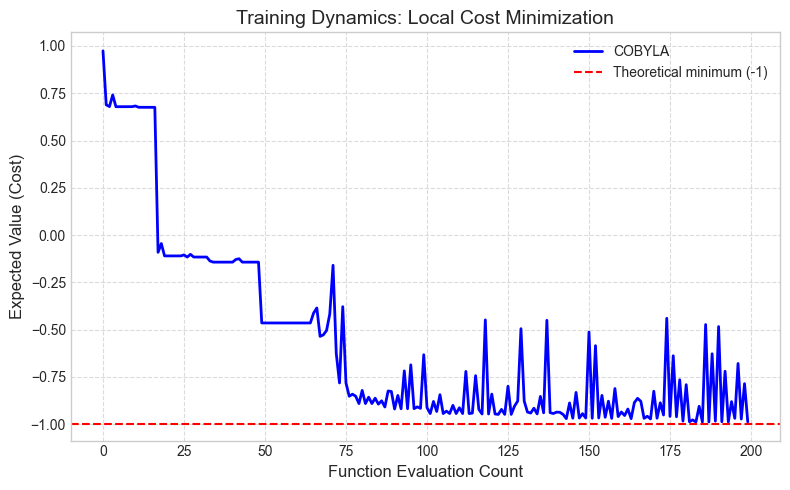

In [16]:
# Variable to store training history
cobyla_cost_history = []

# 3. Objective function
def objective_function(parameters):
    # Evaluate the circuit at current parameters
    pub = (ansatz, observable, [parameters])
    result = estimator.run([pub]).result()[0]
    cost = result.data.evs[0]

    # Save value for plotting
    cobyla_cost_history.append(cost)
    return cost

# 4. Optimizer initialization and execution
print(f"Starting training with COBYLA ({num_params} parameters)...")


# Instantiate COBYLA with a maximum of 100 iterations
optimizer = COBYLA(maxiter=200)

# Execute minimization
result_cobyla = optimizer.minimize(fun=objective_function, x0=initial_parameters)

print("Training completed.")
print(f"Minimum value reached: {result_cobyla.fun:.4f}")

# 5. Results visualization
plt.figure(figsize=(8, 5))
plt.plot(cobyla_cost_history, label='COBYLA', color='blue', linewidth=2)
plt.axhline(y=-1.0, color='r', linestyle='--', label='Theoretical minimum (-1)')

plt.title('Training Dynamics: Local Cost Minimization', fontsize=14)
plt.xlabel('Function Evaluation Count', fontsize=12)
plt.ylabel('Expected Value (Cost)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_20808\1434120553.py:5: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz_local = EfficientSU2(num_qubits=n_qubits_local, reps=reps_local, entanglement='linear')


Running COBYLA...
-> COBYLA stopped early at evaluation 274.
Running QNSPSA...
-> QNSPSA stopped early at evaluation 2915.


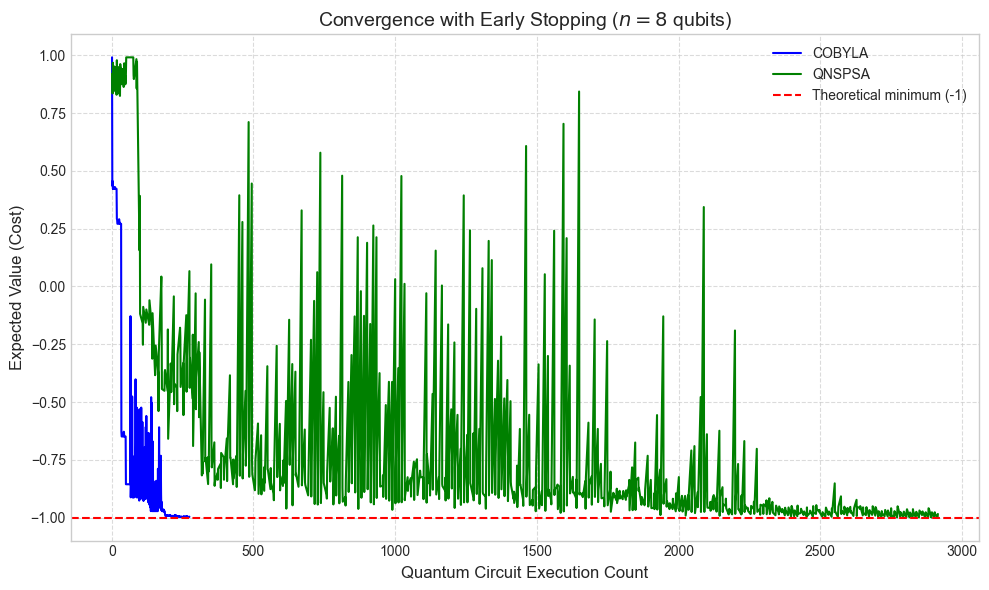

In [26]:
# COBYLA vs QNSPSA with early stopping (8 qubits)

n_qubits_local = 8
reps_local = max(1, int(np.round(np.log2(n_qubits_local))))
ansatz_local = EfficientSU2(num_qubits=n_qubits_local, reps=reps_local, entanglement='linear')
observable_local = SparsePauliOp.from_list([("I" * (n_qubits_local - 1) + "Z", 1)])
initial_parameters_local = np.random.normal(loc=0.0, scale=0.1, size=ansatz_local.num_parameters)
estimator_local = StatevectorEstimator()

history, counts = init_trackers("cobyla", "qnspsa")

objective_cobyla = with_early_stopping(
    make_objective(
        "cobyla",
        counts=counts,
        history=history,
        estimator=estimator_local,
        ansatz=ansatz_local,
        observable=observable_local,
    ),
    history=history,
    key="cobyla",
    window=WINDOW_EVALS,
    tolerance=TOLERANCE,
    stop_exception=ConvergenceReached,
 )

objective_qnspsa = with_early_stopping(
    make_objective(
        "qnspsa",
        counts=counts,
        history=history,
        estimator=estimator_local,
        ansatz=ansatz_local,
        observable=observable_local,
    ),
    history=history,
    key="qnspsa",
    window=WINDOW_EVALS,
    tolerance=TOLERANCE,
    stop_exception=ConvergenceReached,
 )

fidelity = make_fidelity(counts=counts, key="qnspsa", circuit=ansatz_local)

run_optimizer(
    "cobyla",
    COBYLA(maxiter=500),
    objective_cobyla,
    initial_parameters_local,
    stop_exception=ConvergenceReached,
    counts=counts,
 )

run_optimizer(
    "qnspsa",
    QNSPSA(fidelity=fidelity, maxiter=500),
    objective_qnspsa,
    initial_parameters_local,
    stop_exception=ConvergenceReached,
    counts=counts,
 )

plt.figure(figsize=(10, 6))
plt.plot(history["cobyla"]["evals"], history["cobyla"]["cost"], label="COBYLA", color="blue")
plt.plot(history["qnspsa"]["evals"], history["qnspsa"]["cost"], label="QNSPSA", color="green")
plt.axhline(y=-1.0, color="r", linestyle="--", label="Theoretical minimum (-1)")
plt.title(f"Convergence with Early Stopping ($n={n_qubits_local}$ qubits)", fontsize=14)
plt.xlabel("Quantum Circuit Execution Count", fontsize=12)
plt.ylabel("Expected Value (Cost)", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_20808\1950149466.py:9: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement='linear')


Running COBYLA...
Running QNSPSA...


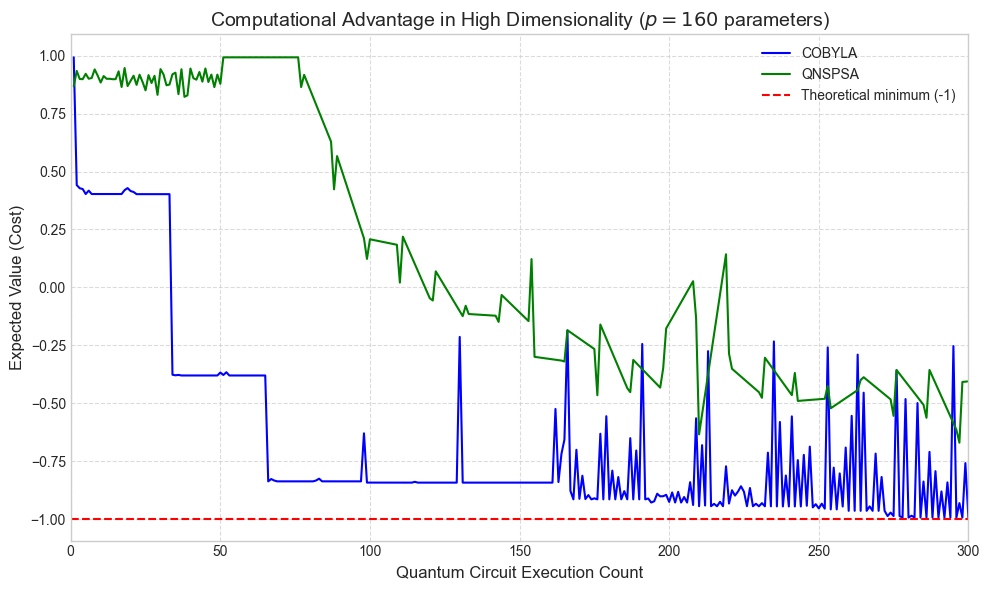

In [ ]:
# 1. High-dimensionality system setup
n_qubits = 16

reps_log = max(1, int(np.round(np.log2(n_qubits))))

ansatz = EfficientSU2(num_qubits=n_qubits, reps=reps_log, entanglement='linear')
observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])

num_params = ansatz.num_parameters
initial_parameters = np.random.normal(loc=0.0, scale=0.1, size=num_params)

estimator = StatevectorEstimator()

# 2. Shared containers and counters
history, counts = init_trackers("cobyla", "qnspsa")

objective_cobyla = make_objective(
    "cobyla",
    counts=counts,
    history=history,
    estimator=estimator,
    ansatz=ansatz,
    observable=observable,
)
objective_qnspsa = make_objective(
    "qnspsa",
    counts=counts,
    history=history,
    estimator=estimator,
    ansatz=ansatz,
    observable=observable,
)
fidelity = make_fidelity(counts=counts, key="qnspsa", circuit=ansatz)

# 3. Optimizer execution (limited by iteration budget)
# COBYLA uses maxiter as a function-evaluation cap in its SciPy backend.
run_optimizer("cobyla", COBYLA(maxiter=300), objective_cobyla, initial_parameters)

# QNSPSA uses maxiter as update steps.
# We use fewer steps to approximately match the total evaluation budget.
run_optimizer("qnspsa", QNSPSA(fidelity=fidelity, maxiter=50), objective_qnspsa, initial_parameters)

# 4. Convergence plot
plt.figure(figsize=(10, 6))
plt.plot(history["cobyla"]["evals"], history["cobyla"]["cost"], label="COBYLA", color="blue")
plt.plot(history["qnspsa"]["evals"], history["qnspsa"]["cost"], label="QNSPSA", color="green")

plt.axhline(y=-1.0, color="r", linestyle="--", label="Theoretical minimum (-1)")
plt.title(f"Computational Advantage in High Dimensionality ($p={num_params}$ parameters)", fontsize=14)
plt.xlabel("Quantum Circuit Execution Count", fontsize=12)
plt.ylabel("Expected Value (Cost)", fontsize=12)

# Limit the x-axis to 300 evaluations to compare equal budgets
plt.xlim(0, 300)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_20808\901244703.py:8: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=layers, entanglement='linear')


Running COBYLA with shot noise (99 shots)...
Running COBYLA...
Running QNSPSA with shot noise (99 shots)...
Running QNSPSA...


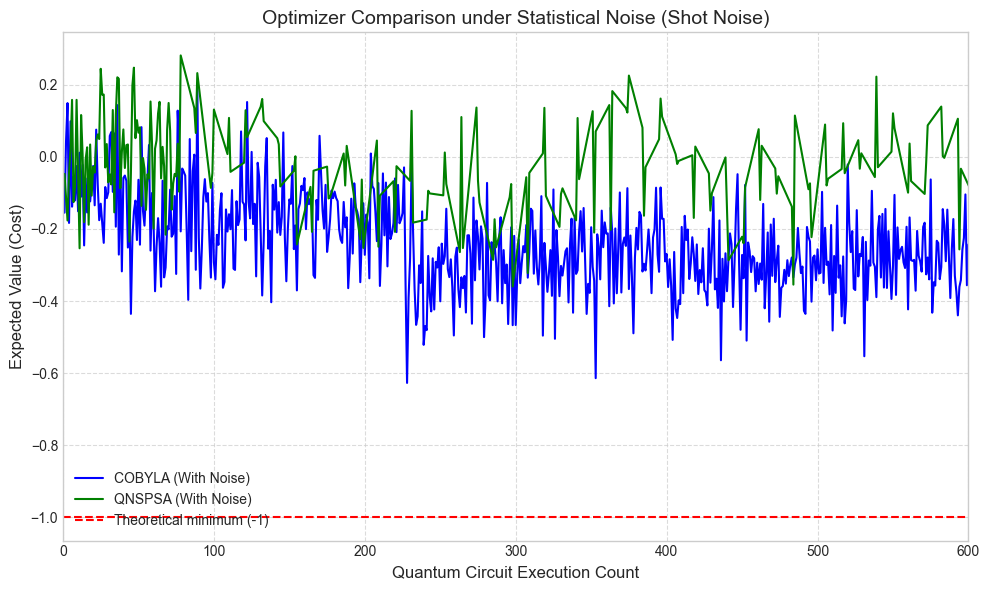

In [25]:
# Shot noise (12 qubits)
# Global imports are already loaded in the configuration section.
from qiskit_aer.primitives import EstimatorV2

# 1. Shot-noise system setup
n_qubits = 12
layers = 8
ansatz = EfficientSU2(num_qubits=n_qubits, reps=layers, entanglement='linear')
observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])
num_params = ansatz.num_parameters

# Decomposed circuit for this section
ansatz_decomposed = ansatz.decompose()

# Precision -> approximate shot budget
target_precision = 0.1
num_shots = int(1 / (target_precision ** 2))

# Noisy estimator configuration
estimator = EstimatorV2(options={"default_precision": target_precision})

# Shared initialization
np.random.seed(42)
p0 = np.random.uniform(-np.pi, np.pi, num_params)

# 2. Shared containers and counters
history, counts = init_trackers("cobyla", "qnspsa")

objective_cobyla = make_objective(
    "cobyla",
    counts=counts,
    history=history,
    estimator=estimator,
    ansatz=ansatz_decomposed,
    observable=observable,
)
objective_qnspsa = make_objective(
    "qnspsa",
    counts=counts,
    history=history,
    estimator=estimator,
    ansatz=ansatz_decomposed,
    observable=observable,
)
fidelity = make_fidelity(counts=counts, key="qnspsa", circuit=ansatz_decomposed)

# 3. Optimizer runs
MAX_ITER = 600

print(f"Running COBYLA with shot noise ({num_shots} shots)...")
run_optimizer("cobyla", COBYLA(maxiter=MAX_ITER), objective_cobyla, p0)

print(f"Running QNSPSA with shot noise ({num_shots} shots)...")
run_optimizer("qnspsa", QNSPSA(fidelity=fidelity, maxiter=50), objective_qnspsa, p0)

# 4. Convergence plot
plt.figure(figsize=(10, 6))
plt.plot(history["cobyla"]["evals"], history["cobyla"]["cost"], label="COBYLA (With Noise)", color="blue")
plt.plot(history["qnspsa"]["evals"], history["qnspsa"]["cost"], label="QNSPSA (With Noise)", color="green")

plt.axhline(y=-1.0, color="r", linestyle="--", label="Theoretical minimum (-1)")
plt.title("Optimizer Comparison under Statistical Noise (Shot Noise)", fontsize=14)
plt.xlabel("Quantum Circuit Execution Count", fontsize=12)
plt.ylabel("Expected Value (Cost)", fontsize=12)
plt.xlim(0, MAX_ITER)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()